Using Data from RTO2000 Scope

The data is in the .wfm.bin files, the .bin file with the same name is a header file which contains acquisition parameters (including resolution)

The data is exported as 32-bit floating point data (float32)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Import and arrange data

In [6]:

file_path = Path("2-19 Intrinsic Waveforms/AVG.Wfm.bin")
dtype = np.float32     # Set data type
resolution = 1e-12
vertical_step = 1           # volts per count 

# Load binary waveform
data = np.fromfile(file_path, dtype=dtype)

# Scale data
waveform = data * vertical_step * 1e3 # in mV

# Set time axis
t = (np.arange(len(waveform)) - len(waveform)/2) * resolution *1e9 # centered at 0, units of ns

### Compute Rise Time and Plot

In [7]:
def compute_rise_time(t, v):

    # Find minimum (pulse peak)
    min_index = np.argmin(v)
    vmin = v[min_index]

    # Define 10% and 90% levels
    level_10 = 0.1 * vmin
    level_90 = 0.9 * vmin

    # Find crossing indices (search only before the minimum)
    pre_pulse = v[:min_index]

    idx_10 = np.where(pre_pulse <= level_10)[0][0]
    idx_90 = np.where(pre_pulse <= level_90)[0][0]

    # Linear interpolation for better precision (Not using)
    def interpolate_crossing(i, level):
        x0, x1 = t[i-1], t[i]
        y0, y1 = v[i-1], v[i]
        return x0 + (level - y0) * (x1 - x0) / (y1 - y0)

    # t10 = interpolate_crossing(idx_10, level_10)
    # t90 = interpolate_crossing(idx_90, level_90)

    t10 = t[idx_10]
    t90 = t[idx_90]

    rise_time = t90 - t10
    return round(rise_time, 5), t10, t90

rise_time, t10, t90 = compute_rise_time(t, waveform)
print(rise_time, t10, t90)


3.979 -3.8950000000000005 0.08399999999999999


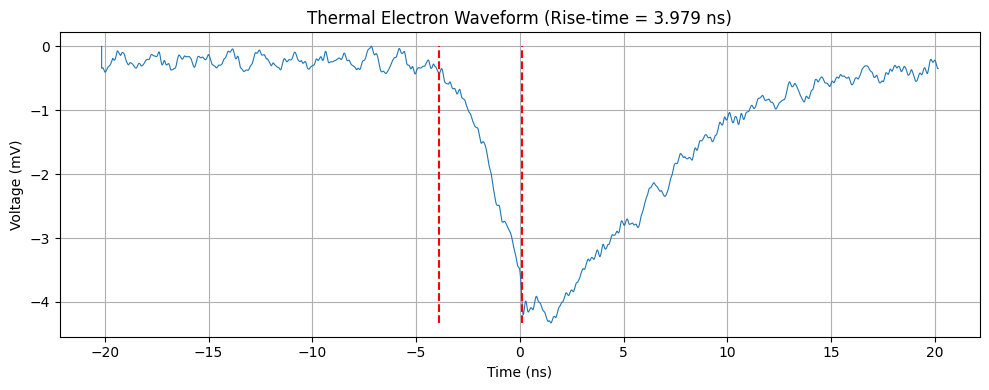

Rise time: 3.979 ns


In [9]:
plt.figure(figsize=(10, 4))
plt.plot(t, waveform, lw=0.8)
plt.vlines([t10, t90], ymin = waveform[np.argmin(waveform)], ymax=0, colors="red", linestyles='--')

plt.xlabel("Time (ns)")
plt.ylabel("Voltage (mV)")
plt.title(f"Thermal Electron Waveform (Rise-time = {rise_time} ns)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Rise time:", rise_time, "ns")
